In [1]:
using GenLAProblems, LinearAlgebra, RowEchelon, Latexify, LaTeXStrings, Random;

<div style="float:center;width:100%;text-align:center;">
<strong style="height:100px;color:darkred;font-size:40px;">Problem Review</strong>
</div>

# 1. GE/GJ Problems

## 1.1 Gaussian Elimination (GE)

### 1.1.1  GE and Backsubstitution

#### **Consistent System**

In [43]:
M=3; N=5; r=3  # M is the number of rows, N the number of cols, r the number of pivots
# --------------------------------------------------------
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)
pb_ge = ShowGe{Rational{Int}}( A,  B, tmp_dir="tmp")
l_show( L"A =", A, L"\quad b=", B, inline=true)

L"$A = \left(\begin{array}{rrrrr}
-2 & 1 & -3 & 2 & -5 \\
4 & -1 & 5 & -2 & 4 \\
-2 & 0 & -2 & 1 & -1 \\
\end{array}\right) \quad b= \left(\begin{array}{r}
7 \\
-11 \\
6 \\
\end{array}\right)$
"

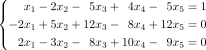

In [31]:
show_system( pb_ge, b_col=1, fig_scale=1.2 )

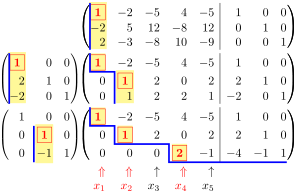

In [32]:
ref!(pb_ge, gj=false)               # perform gaussian elimination
show_layout!(pb_ge, fig_scale=1.2)  # show the computational layout

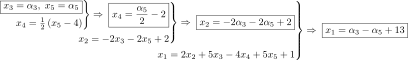

In [33]:
show_backsubstitution!(pb_ge, b_col=1)

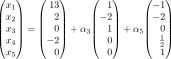

In [34]:
show_solution!(pb_ge, b_col=1)

In [35]:
Xp, Xh = solutions(pb_ge)
l_show( L"B =", pb_ge.B, L"\quad x_p =", Xp, L"\quad x_h = ", Xh)

L"$B = \left(\begin{array}{rrr}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}\right) \quad x_p = \frac{1}{2} \left(\begin{array}{rrr}
26 & 8 & -4 \\
4 & 2 & 0 \\
0 & 0 & 0 \\
-4 & -1 & 1 \\
0 & 0 & 0 \\
\end{array}\right) \quad x_h = \frac{1}{2} \left(\begin{array}{rr}
2 & -2 \\
-4 & -4 \\
2 & 0 \\
0 & 1 \\
0 & 2 \\
\end{array}\right)$
"

In [37]:
# check the solution
@show pb_ge.A * Xp == pb_ge.B;

pb_ge.A * Xp == pb_ge.B = true


In [41]:
display( pr( "Details of the computations are kept in the ShowGE{} structure"; color=:blue, sz=20, height=25 ))
for name in fieldnames(typeof(pb_ge))
  if isdefined(pb_ge, name)
     if name == :desc || name == :h
          println(name, " ... ")
      else
          println(name, " = ", getfield(pb_ge, name))
      end
  else
      println(name, " = <undef>")
  end
end

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%;\">\n  <p>Details of the computations are kept in the ShowGE{} structure</p>\n</div>\n")

tmp_dir = tmp
keep_file = tmp/show_layout
A = Rational{Int64}[1 -2 -5 4 -5; -2 5 12 -8 12; 2 -3 -8 10 -9]
B = Rational{Int64}[1 0 0; 0 1 0; 0 0 1]
num_rhs = 3
normal_eq = false
matrices = Vector{Union{Nothing, Matrix{Rational{Int64}}}}[[nothing, Rational{Int64}[1 -2 -5 4 -5 1 0 0; -2 5 12 -8 12 0 1 0; 2 -3 -8 10 -9 0 0 1]], [Rational{Int64}[1 0 0; 2 1 0; -2 0 1], Rational{Int64}[1 -2 -5 4 -5 1 0 0; 0 1 2 0 2 2 1 0; 0 1 2 2 1 -2 0 1]], [Rational{Int64}[1 0 0; 0 1 0; 0 -1 1], Rational{Int64}[1 -2 -5 4 -5 1 0 0; 0 1 2 0 2 2 1 0; 0 0 0 2 -1 -4 -1 1]]]
cascade = <undef>
pivot_cols = [1, 2, 4]
free_cols = [3, 5]
desc ... 
pivot_list = Vector{Any}[[(1, 1), [(0, 0), (1, 1)]], [(2, 0), [(1, 1)]], [(0, 1), [(0, 0)]], [(2, 1), [(0, 0), (1, 1), (2, 3)]], [(1, 0), [(0, 0)]]]
bg_for_entries = Vector[Vector{Any}[[1, 1, [(0, 0), (1, 1)], "yellow!40"], [1, 1, Any[(1, 1), [(1, 1), (2, 1)]], "yellow!40", 1]], Any[2, 0, Any[(1, 1), [(1, 1), (2, 1)]], "yellow!40", 1], Vector{Any}[[0, 1, [(0, 0)], "yellow!4

#### **Inconsistent System**

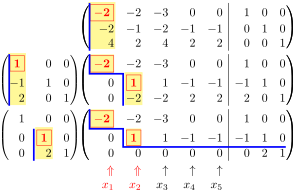

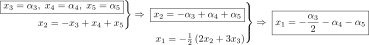

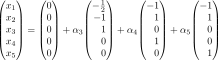

L"$B = \left(\begin{array}{rrr}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}\right) \quad x_p = \frac{1}{2} \left(\begin{array}{rrr}
1 & -2 & 0 \\
-2 & 2 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{array}\right) \quad x_h = \frac{1}{2} \left(\begin{array}{rrr}
-1 & -2 & -2 \\
-2 & 2 & 2 \\
2 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 2 \\
\end{array}\right)$
"

In [48]:
Random.seed!(4562)
A,X,B = gen_gj_pb(3,5,2; maxint=2, pivot_in_first_col=true, num_rhs=0,has_zeros=true)
pb_x = ShowGe{Rational{Int}}( A,  Matrix(one(eltype(A))I(M)), tmp_dir="tmp")
ref!(pb_x, gj=false)               # perform gaussian elimination
display(show_layout!(pb_x, fig_scale=1.2))  # show the computational layout
display(show_backsubstitution!(pb_x, b_col=3))
display(show_solution!(pb_x, b_col=3))
Xp, Xh = solutions(pb_x)
display(l_show( L"B =", pb_x.B, L"\quad x_p =", Xp, L"\quad x_h = ", Xh))

### **What can we do with GE?**

#### Read out the following Information
* solve $A x = b$;  particular solution/homogeneous solution
* LU decomposition / solve L U x = b with forward/backward steps
* bases for the fundamental subspaces (note $\mathscr{N}(A)$ requires solving $A x = 0$.)
* find linear dependent/independent vectors

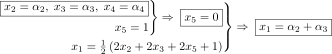

In [5]:
show_backsubstitution!(pb_ge, b_col=1, fig_scale=1.2) # show the bacsubstitution

### 1.1.2 Special Case Normal Equation
* least squares solution  (note: the problem may be defined in terms of a table)

In [6]:
M=3; N=4; r=2
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)
pb_least_squares = ShowGe{Rational{Int}}( A, B, tmp_dir="tmp")
l_show( L"A =", A, L"\quad b=", B, inline=true)

L"$A = \left(\begin{array}{rrrr}
1 & -1 & 1 & -1 \\
1 & -2 & 3 & 0 \\
2 & -2 & 2 & -2 \\
\end{array}\right) \quad b= \left(\begin{array}{r}
1 \\
1 \\
2 \\
\end{array}\right)$
"

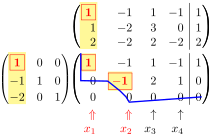

In [7]:
ref!(pb_least_squares, normal_eq=true)
show_layout!(pb_least_squares, fig_scale=1.2)

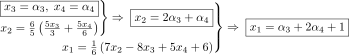

In [8]:
show_backsubstitution!(pb_least_squares, b_col=1, fig_scale=1.2)

### 1.1.3 Special Case A square of size $N \times N$

* could remove cols in a GE pb to make A square
  * find the determinant
  * find the inverse

In [9]:
M=3; N=3; r=3; num_rhs=0
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=num_rhs,has_zeros=true)

pb_square = ShowGe{Rational{Int}}( A,  [B I], tmp_dir="tmp")
l_show( L"A =", A, inline=true) #, L"\quad b=", B, inline=true)

L"$A = \left(\begin{array}{rrr}
1 & 0 & 4 \\
2 & 2 & 4 \\
2 & 4 & -2 \\
\end{array}\right)$
"

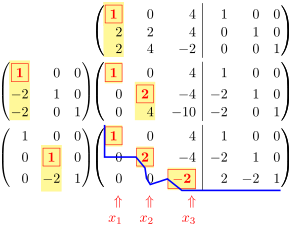

In [10]:
ref!(pb_square)
show_layout!(pb_square, fig_scale=1.4)

## 1.2 Gauss-Jordan Elimination (GJ)

In [11]:
M=3; N=3; r=3
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)

pb_gj = ShowGe{Rational{Int}}( A,  Matrix(one(eltype(A))I(M)), tmp_dir="tmp")
l_show( L"A =", A, L"\quad b=", Matrix(one(eltype(A))I(M)), inline=true)

L"$A = \left(\begin{array}{rrr}
2 & 2 & 0 \\
-2 & 0 & -2 \\
4 & 2 & 3 \\
\end{array}\right) \quad b= \left(\begin{array}{rrr}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}\right)$
"

#### What Can we do with GJ?
* find rref(A)
* solve $A x = b$
* CR decomposition
* Inverse

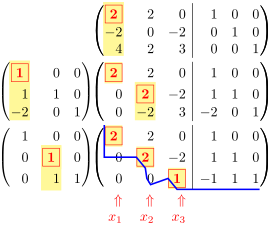

In [12]:
ref!(pb_gj, gj=true)
show_layout!(pb_gj, fig_scale=1.4)

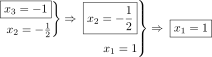

In [13]:
show_backsubstitution!(pb_gj, b_col=1, fig_scale=1.2)

## 1.3 Inverse Problems

In [14]:
A, A_inv                = gen_inv_pb(3, maxint=3)
matrices, pivot_cols, _ = reduce_to_ref( Rational{Int64}.([A 1I]), gj=true)

h = nM.ge( to_latex(matrices), formater=x->x, Nrhs=size(A,1), tmp_dir="../../tmp" )
h

LoadError: Python: PermissionError: [Errno 13] Permission denied: '../../tmp'
[0mPython stacktrace:
[0m [1] [0m[1mmkdir[22m
[90m   @ [39m[35mpathlib [39m[90m/usr/local/lib/python3.11/pathlib.py:1116[39m
[0m [2] [0m[1mrender_svg_with_artifacts[22m
[90m   @ [39m[36mmatrixlayout.render [39m[90m/opt/ea42gh/matrixlayout/matrixlayout/render.py:69[39m
[0m [3] [0m[1mrender_svg[22m
[90m   @ [39m[36mmatrixlayout.render [39m[90m/opt/ea42gh/matrixlayout/matrixlayout/render.py:108[39m
[0m [4] [0m[1mrender_ge_svg[22m
[90m   @ [39m[36mmatrixlayout.ge [39m[90m/opt/ea42gh/matrixlayout/matrixlayout/ge.py:3226[39m
[0m [5] [0m[1mge[22m
[90m   @ [39m[32mla_figures.ge_convenience [39m[90m/opt/ea42gh/la_figures/la_figures/ge_convenience.py:952[39m

# 2. QR

In [ ]:
#A = gen_qr_problem(4; maxint=2)
A = gen_qr_problem_3(maxint=2)
A = A[:,1:3]
l_show(L"A =", A, inline=true)

In [ ]:
W   = gram_schmidt_w(A)
h,m = nM.gram_schmidt_qr(A, fig_scale=1.2, tmp_dir="tmp")
h

# 3. Eigenproblems

## 3.1 General Case

In [ ]:
S,Λ,Sinv,A = gen_eigenproblem([-2,-2,0])
d,intA     = factor_out_denominator(A)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))", inline=true )

In [ ]:
svg,spec = nM.show_eig_tbl(intA,Ascale=d, fig_scale=1.4, tmp_dir="tmp" )

## 3.2 Failure

In [ ]:
A       = gen_non_diagonalizable_eigenproblem(2,0)
#d,intA  = factor_out_denominator(A)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))", inline=true )

In [ ]:
svg,spec = nM.show_eig_tbl(intA,Ascale=d, fig_scale=1.4, tmp_dir="tmp" )

## 3.3 Symmetric Matrix

In [ ]:
S,Λ,A   = gen_symmetric_eigenproblem([2,1,0], maxint=2)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))", inline=true )

In [ ]:
d,intA  = factor_out_denominator(A)
svg,spec = nM.show_eig_tbl(intA,Ascale=d,normal=true, fig_scale=1.4, tmp_dir="tmp" )

## 3.4 Functions of a Matrix

Eigendecomposition $A = S \Lambda S^{-1} \Rightarrow A^n = S \Lambda^n S^{-1}$

## 3.5 SVD

In [ ]:
M=3; N=[3,1]; sigmas=[1,-1]   # by splitting N or M into a list of integers
#                             # the matrices become simpler. Here M=3, N=3+1
# ------------------------------------------------------------
U,Σ,Vt,A = gen_svd_problem(3, [3,1],  [1,-1],  maxint=2)

l_show(L"A = ", A, L", \qquad A^{t} A =", A'A, inline=true )

In [ ]:
dA,intA  = factor_out_denominator(A)
svg,spec = nM.show_svd_table(intA, Ascale=dA, fig_scale=1.4, tmp_dir="tmp")

#### PseudoInverse

In [ ]:
r    = length(sigmas)
U_r  = U[:,1:r];   dU_r,intU_r = factor_out_denominator(U_r)
V_r  = Matrix(Vt[1:r,:]'); dV_r,intV_r = factor_out_denominator(V_r)
Σ_r  = Σ[1:r,1:r]
dinvΣ_r, invΣ_r = factor_out_denominator(Matrix(Diagonal([1//k for k in diag(Σ_r)])))
pinv_A = V_r * dinvΣ_r * invΣ_r * U_r'

l_show( L"A^\dagger = V_r \Sigma_r^{-1} U_r^t = ",
        V_r, Σ_r, U_r',
        L"= ", pinv_A,
)

In [ ]:
@show Float64.(pinv_A) ≈ pinv(A);